# VCO

## Generate spice net list from xschem

In [1]:
!xschem -n -s -x -q -o netlist tb_vco_tran.sch

Using run time directory XSCHEM_SHAREDIR = /foss/tools/xschem/share/xschem
Sourcing /foss/tools/xschem/share/xschem/xschemrc init file
Sourcing /headless/.xschem/xschemrc init file
pdk installation: using /foss/pdks
180MCU_MODELS: /foss/pdks/gf180mcuD/libs.tech/ngspice
setup_tcp_bespice: success : listening to TCP port: 2022



## Execute ngspice and generate output result text file

In [2]:
!ngspice -b netlist/tb_vco_tran.spice


Note: No compatibility mode selected!


Circuit: ** sch_path: /foss/designs/03_super_long_wave/2026_sscs_gf180/designs/libs/tb_analog/tb_vco/tb_vco_tran.sch

count_length:39
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using SPARSE 1.3 as Direct Linear Solver

Initial Transient Solution
--------------------------

Node                                   Voltage
----                                   -------
out1_n                                 2.45834
out1_p                                 2.45834
net4                                   1.54096
net5                                   1.54096
net1                                  0.705102
net3                                  0.704705
net2                                  0.705102
vdd                                        3.3
net6                                   2.46094
net9                                   1.62188
net7                                   1.52913
net8                                   2.45913
out2         

## Visualize results

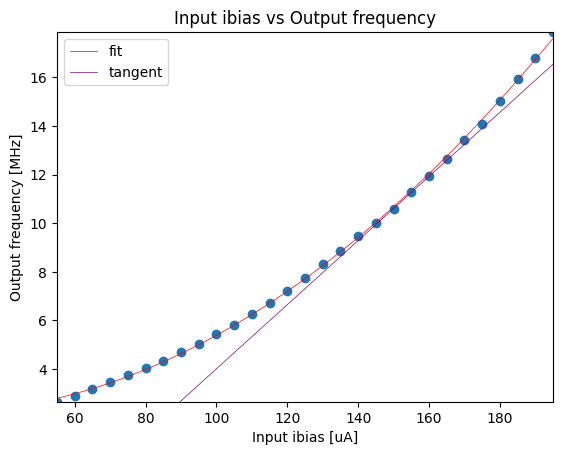

current_at_if:150.73[uA] frequency:10700000.0
deriv_at_if[KHz/uA]:131.78
vco_fit2nd:[ 5.06831547e+14 -2.10092307e+10  2.42163109e+06]
fc:10700000.0[Hz]
delta_f:75000.0[Hz]
beta:5.0
bt:180000.0[Hz]
kf:375000.0[Hz/V]
am:0.2[V]
ota_transconductance:2.845656761779913e-06[S]
ota_resistance:351412.72602902254[ohm]
output_frequency:11075000.0[Hz]


In [6]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

vco_df = pd.read_csv("tb_vco_freq.txt", sep=r"\s+", header=0)
vco_df.columns = ["input_ibias", "output_frequency"]
vco_df=vco_df.drop(vco_df.index[0:10])
vco_fit2nd=np.polyfit(vco_df["input_ibias"], vco_df["output_frequency"], 2)
kcco= np.sum(vco_df["input_ibias"] * vco_df["output_frequency"]) / np.sum(vco_df["input_ibias"]**2)
vco_df["2nd_poly_fit"] = np.poly1d(vco_fit2nd)(vco_df["input_ibias"]) 

f_freq_to_current = interpolate.interp1d(vco_df["output_frequency"],vco_df["input_ibias"])

intermidiate_frequency =10.7e6
deriv=[2*vco_fit2nd[0], vco_fit2nd[1]]
vco_df["deriv"] = np.poly1d(deriv)(vco_df["input_ibias"]) 
f_current_to_deriv = interpolate.interp1d(vco_df["input_ibias"],vco_df["deriv"])

current_at_if =f_freq_to_current(intermidiate_frequency)
deriv_at_if = f_current_to_deriv(current_at_if)
tangent_at_if=(vco_df["input_ibias"]-current_at_if)*deriv_at_if+intermidiate_frequency
plt.plot(vco_df["input_ibias"]*1e6, vco_df["2nd_poly_fit"]/1e6,color="red",linestyle = "-",linewidth=0.5,label="fit")
plt.plot(vco_df["input_ibias"]*1e6, tangent_at_if/1e6,color="purple",linestyle = "-",linewidth=0.5,label="tangent")

plt.scatter(vco_df["input_ibias"]*1e6, vco_df["output_frequency"]/1e6)
plt.title("Input ibias vs Output frequency")
plt.xlabel("Input ibias [uA]")
plt.ylabel("Output frequency [MHz]")
plt.xlim(min(vco_df["input_ibias"])*1e6,max(vco_df["input_ibias"])*1e6)
plt.ylim(min(vco_df["output_frequency"])/1e6,max(vco_df["output_frequency"])/1e6)

plt.legend()
plt.show()
print(f"current_at_if:{current_at_if*1e6:.2f}[uA] frequency:{intermidiate_frequency}")
print(f"deriv_at_if[KHz/uA]:{deriv_at_if*1e-9:.2f}")

print(f"vco_fit2nd:{vco_fit2nd}")
# FM modulation
fc = 10.7e6 # Intermediate Frequency : 10.7MHz

delta_f = 75e3 # max frequency deviation 75khz
fm = 15e3 # modulating freqeuncy : max audio frequency 15khz
beta = delta_f/fm # modulation index
bt = 2*fm*(beta+1) # FM bandwidth
am = 0.2 # Max amplitude of message signal
kf = delta_f/am # 25e3 # frequency sensitivity factor [Hz/V]

# Display the transfer function
print(f"fc:{fc}[Hz]")
print(f"delta_f:{delta_f}[Hz]")
print(f"beta:{beta}")
print(f"bt:{bt}[Hz]")
print(f"kf:{kf}[Hz/V]")
print(f"am:{am}[V]")

# calculate OTA
ota_transconductance=kf/deriv_at_if
ota_resistance=deriv_at_if/kf

input_signal_volt=1
output_frequency=intermidiate_frequency+(input_signal_volt/ota_resistance)*deriv_at_if
print(f"ota_transconductance:{ota_transconductance}[S]")
print(f"ota_resistance:{ota_resistance}[ohm]")
print(f"output_frequency:{output_frequency}[Hz]")